# Lecture 03 · Build the Archer 🏹  — Policy Gradients from scratch

**RL in Production · Vizuara AI Labs**

In the lecture you met the Archer: a one-state **bandit** (nine firing angles), then
an **MDP** where the archer can *walk* before it shoots. In this assignment you
build that exact world in code and climb the **variance ladder** the lecture is
organised around:

> **REINFORCE → REINFORCE + baseline → Actor-Critic**

You will implement each method **from scratch in PyTorch** (no Stable-Baselines3),
watch the nine-angle fan sharpen, teach the archer to walk in before shooting, and
**measure the gradient variance** drop as you add a baseline and then a critic.

**Cells marked ✅ PROVIDED are complete — run them. Cells marked 📝 TODO are yours
to finish** (each is one or two lines, with the equation from the slide right next
to it). Everything downstream calls your code, so fill the TODOs top to bottom.

Runs on a free CPU Colab in a few minutes.

In [1]:
# ✅ PROVIDED — setup
import numpy as np, torch, torch.nn as nn
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
torch.manual_seed(0); np.random.seed(0)
GAMMA = 0.95

## Part 0 · The Archer worlds and the networks (✅ provided)

Two custom `gymnasium` environments — exactly the ones from the slides.

In [3]:
# ✅ PROVIDED — the two Archer environments (with detailed comments)

class ArcherBandit(gym.Env):
    """
    ArcherBandit Environment:
    - One-state bandit environment where the agent chooses one of 9 firing angles (discrete actions).
    - The reward is determined by how close the chosen angle is to the central "bullseye" (TARGET).
    - Reward function: Gaussian centered at the bullseye.
    """
    N_ANGLES, TARGET, SIGMA = 9, 4, 1.5  # 9 actions, bullseye at action 4, Gaussian σ=1.5

    def __init__(self):
        super().__init__()
        # Only one state; state does not change, so observation always [0.]
        self.observation_space = spaces.Box(0., 1., (1,), np.float32)  
        # 9 discrete actions (fire at one of 9 angles)
        self.action_space = spaces.Discrete(self.N_ANGLES)

    def reset(self, *, seed=None, options=None):
        # Resets environment (single-state): always returns observation [0.]
        super().reset(seed=seed)
        return np.array([0.], np.float32), {}

    def step(self, a):
        # Compute reward: the closer a (the selected angle) is to TARGET, the higher the reward
        # Gaussian: exp(-((a - TARGET)^2) / (2 * SIGMA^2))
        r = float(np.exp(-((a - self.TARGET)**2) / (2*self.SIGMA**2)))
        # Returns: next_state, reward, terminated, truncated, info
        # Episode always ends after one step (bandit problem)
        return np.array([0.], np.float32), r, True, False, {}

class ArcherMDP(gym.Env):
    """
    ArcherMDP Environment:
    - MDP with distance-to-target as the state.
    - Actions: 
        0 = step closer (decrease distance by 10), 
        1 = step back (increase distance by 10),
        2 = shoot (terminate/earn a shooting reward based on distance to target).
    - Each step (walk) costs -0.2 reward.
    - Shooting rewards: higher when closer to target (max +10 at 10m, min -1.2 at 50m).
    - Agent starts at a random distance (chosen from five options) and can move for up to ``max_steps`` before truncation.
    """
    CLOSER, BACK, SHOOT = 0, 1, 2            # Action indices: step closer, back, or shoot
    MIN_D, MAX_D = 10., 50.                  # Minimum and maximum possible distances

    def __init__(self, max_steps=25):
        super().__init__()
        # State is normalized distance (in [0, 1])
        self.observation_space = spaces.Box(0., 1., (1,), np.float32)
        # Three discrete actions (walk closer/back, or shoot)
        self.action_space = spaces.Discrete(3)
        self.max_steps = max_steps           # Max steps per episode before truncation

    def _obs(self):
        # Returns normalized distance state: d / MAX_D, as required by observation_space
        return np.array([self.d / self.MAX_D], np.float32)

    def reset(self, *, seed=None, options=None):
        # Reset state: choose random initial distance (among {10, 20, 30, 40, 50})
        super().reset(seed=seed)
        self.d = float(self.np_random.choice([10.,20.,30.,40.,50.]))
        self.t = 0  # Reset step counter
        return self._obs(), {}

    def shoot_reward(self, d):
        # Reward for shooting at distance d: linearly decreases from +10 (10m) to -1.2 (50m)
        return 10. - 0.28*(d - self.MIN_D)

    def step(self, a):
        self.t += 1  # Increment step counter
        if a == self.SHOOT:
            # If action is SHOOT: episode terminates; receive distance-based reward
            return self._obs(), float(self.shoot_reward(self.d)), True, False, {}
        # Otherwise, move: action 0 decreases distance, action 1 increases distance
        self.d = float(np.clip(self.d + (-10. if a == self.CLOSER else 10.), self.MIN_D, self.MAX_D))
        # Each walk step costs -0.2 reward
        # Episode truncates if step count exceeds max_steps
        return self._obs(), -0.2, False, self.t >= self.max_steps, {}

In [4]:
# ✅ PROVIDED — the policy network (outputs action logits) and value network V(s)
class Policy(nn.Module):
    def __init__(self, obs_dim, n_act, h=64):
        super().__init__()
        # The policy network structure:
        #   - First layer: Linear, maps input (obs_dim-dim state) to hidden dim (h)
        #   - Activation: Tanh, introduces non-linearity
        #   - Second layer: Linear, maps from hidden dim to n_act output logits (one per action)
        self.net = nn.Sequential(
            nn.Linear(obs_dim, h),  # Linear layer for state to hidden
            nn.Tanh(),              # Non-linear activation
            nn.Linear(h, n_act)     # Linear to output logits for each action
        )

    def forward(self, x): 
        # Compute and return raw action logits for input state x
        # These logits parameterize the Categorical policy distribution
        return self.net(x)              # logits

class Value(nn.Module):
    def __init__(self, obs_dim, h=64):
        super().__init__()
        # The value network structure:
        #   - First layer: Linear, maps input state to hidden dim
        #   - Activation: Tanh, non-linearity
        #   - Second layer: Linear, outputs a single scalar (state value V(s))
        self.net = nn.Sequential(
            nn.Linear(obs_dim, h),     # Linear layer from state to hidden
            nn.Tanh(),                 # Non-linear activation
            nn.Linear(h, 1)            # Output single scalar value
        )

    def forward(self, x): 
        # Forward pass computes state-value V(s)
        # Squeeze to remove singleton dimension so output is 1D tensor (batch,)
        return self.net(x).squeeze(-1)  # scalar V(s)

### 📝 TODO 1 — sample an action and get its log-probability

The policy outputs **logits**; turn them into a distribution, **sample** an action,
and return both its **log-probability** and the distribution's **entropy** (we add a
small entropy bonus to keep exploring). This is the `∇log π` machinery from §4.3.

In [5]:
# 📝 TODO 1 — complete the three marked lines
def act(policy, state_np):
    st = torch.tensor(state_np, dtype=torch.float32)
    logits = policy(st)
    dist = torch.distributions.Categorical(logits=logits)   # ✅ provided: turn logits into a categorical policy distribution over actions

    # --- Exploration detail: sample an action using the current policy distribution. 
    # This introduces stochasticity, allowing the agent to try all actions, not just the current favorite.
    action  = dist.sample()   # Sample an action (exploration mechanism)

    # --- Log-probability of the sampled action: vital for policy gradient updates.
    # Used to weight the update direction by how (un)likely the action was under the policy.
    logp    = dist.log_prob(action)

    # --- Entropy of the action distribution: measures uncertainty/exploration.
    # Higher entropy means more exploration; a bonus on this term encourages the agent not to over-commit to one action prematurely.
    entropy = dist.entropy()

    return action, logp, entropy

In [6]:
# ✅ PROVIDED — roll out one full episode using your act()
def run_episode(env, policy):
    s, _ = env.reset(); S, A, logps, ents, R = [], [], [], [], []
    done = False
    while not done:
        a, logp, ent = act(policy, s)
        s2, r, term, trunc, _ = env.step(int(a))
        S.append(s); A.append(int(a)); logps.append(logp); ents.append(ent); R.append(r)
        s = s2; done = term or trunc
    return S, A, logps, ents, R

## Part A · The bandit + REINFORCE

One state, nine angles. There is no future, so the weight on the sampled angle is
simply its **reward** (the §3 bandit). Watch the fan sharpen onto the bullseye.

### 📝 TODO 2 — the REINFORCE update (bandit)

The estimator is $\hat g = r\,\nabla\log\pi(a)$. As a loss to *minimise* (optimizers
descend), that is `loss = -(reward * logp)`. Add the small entropy bonus.

In [7]:
# 📝 TODO 2 — complete the loss line, with detailed explanatory comments
def train_bandit(episodes=1500, lr=0.01, ent_coef=0.1):
    # Create the ArcherBandit environment and policy network.
    # ArcherBandit is a stateless, single-shot environment (multi-armed bandit).
    # Policy has one input (the single state), output size = number of possible angles.
    env = ArcherBandit()
    pol = Policy(1, env.N_ANGLES)
    
    # Adam optimizer for the policy network.
    opt = torch.optim.Adam(pol.parameters(), lr)
    # History list to keep track of episode rewards for plotting/evaluating learning.
    hist = []
    
    # Loop over the specified number of training episodes
    for ep in range(episodes):
        # Generate a trajectory (a single step here) by running the policy once in the bandit environment.
        # returns: S, A, logps, ents, R (lists of states, actions, log-probabilities, entropies, rewards)
        _, _, logps, ents, R = run_episode(env, pol)
        
        # EXTRACT: for the bandit, each trajectory consists of exactly one step, so index 0.
        logp = logps[0]    # log-probability of the taken action under current policy π(a)
        ent = ents[0]      # entropy of action distribution for exploration encouragement
        r = R[0]           # observed reward from the environment
        
        # --- REINFORCE objective for a bandit problem ---
        # The policy gradient estimator is g = r * ∇logπ(a) — i.e., push up the probability of rewarding actions.
        # As a loss to minimize: loss = -(reward * logp)
        # The optimizer attempts to MINIMIZE loss, so we negate.
        #
        # Add an entropy bonus to encourage exploration:
        #   -ent_coef * ent
        # This encourages higher entropy (more random, exploratory behavior), thus avoids early convergence to a suboptimal deterministic policy.
        #
        # Final loss: negative reward-weighted log-probability, plus (negative) entropy bonus.
        loss = -(r * logp) - ent_coef * ent
        
        # Standard PyTorch optimization steps:
        opt.zero_grad()      # Zero previous gradients.
        loss.backward()      # Compute gradients of loss w.r.t. policy parameters.
        opt.step()           # Update policy parameters.
        
        # Log the reward for later analysis/plotting.
        hist.append(r)
    return pol, hist

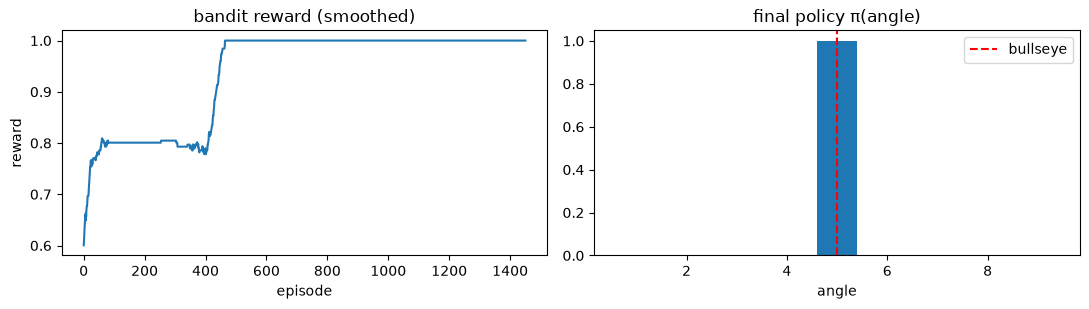

mean reward (last 200): 1.0  (uniform ≈ 0.42)


In [9]:
# ✅ PROVIDED — train and watch the nine-angle fan sharpen
pol_b, hist_b = train_bandit()
probs = torch.softmax(pol_b(torch.zeros(1)), -1).detach().numpy()
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].plot(np.convolve(hist_b, np.ones(50)/50, 'valid')); ax[0].set_title('bandit reward (smoothed)')
ax[0].set_xlabel('episode'); ax[0].set_ylabel('reward')
ax[1].bar(range(1, 10), probs); ax[1].set_title('final policy π(angle)')
ax[1].set_xlabel('angle'); ax[1].axvline(ArcherBandit.TARGET+1, ls='--', c='r', label='bullseye')
ax[1].legend(); plt.tight_layout(); plt.show()
print('mean reward (last 200):', round(np.mean(hist_b[-200:]), 3), ' (uniform ≈ 0.42)')

## Part B · The MDP — REINFORCE → +baseline → Actor-Critic

Now the archer can walk. An action changes the next state, so a single reward
becomes the **return** $G_t$, and we climb the variance ladder.

### 📝 TODO 3 — discounted returns

$G_t = r_t + \gamma r_{t+1} + \gamma^2 r_{t+2} + \dots$  (compute it backwards).

In [10]:
# 📝 TODO 3 — complete the accumulation line
def discounted_returns(rewards, gamma=GAMMA):
    G, out = 0.0, []
    for r in reversed(rewards):
        G = r + gamma * G                 # 📝 TODO: one step of the recursion   (hint: r + gamma * G)
        out.append(G)
    return list(reversed(out))

### 📝 TODO 4 & 5 — REINFORCE, and REINFORCE **+ baseline**

Vanilla REINFORCE weights each step by its return $G_t$. The **baseline** version
subtracts a learned value $V(s_t)$ so the weight becomes the **advantage**
$A_t = G_t - V(s_t)$ — same gradient in expectation, far less noise (§7). The
critic $V$ is trained by regressing onto the returns it saw.

In [11]:
# 📝 TODO 4 & 5 — complete the advantage (and, if baseline, the critic loss)
def reinforce(env, episodes=1500, lr=0.01, baseline=False, ent_coef=0.01):
    """
    Reinforce algorithm for policy gradients.

    If `baseline` is True, a value network is used to reduce variance by subtracting a learned estimate V(s)
    as the baseline from the returns, forming the advantage estimate. The value network is trained via MSE regression
    against the empirical returns. Otherwise, vanilla REINFORCE simply weights the log-probs by the full returns.

    Arguments:
      env: The environment to interact with.
      episodes: Number of episodes for training.
      lr: Learning rate for both policy and value network (if present).
      baseline: If True, use and train a value network (i.e., REINFORCE with baseline).
      ent_coef: Coefficient for the entropy regularization term (encourages exploration).
    
    Returns:
      pol: trained policy network
      val: trained value network (if baseline), else None
      curve: cumulative rewards per episode
    """
    # Initialize the policy network and its optimizer
    pol = Policy(1, env.action_space.n)
    popt = torch.optim.Adam(pol.parameters(), lr)
    
    # If using a baseline, initialize the value network and its optimizer
    val = Value(1) if baseline else None
    vopt = torch.optim.Adam(val.parameters(), lr) if baseline else None

    curve = []  # Track sum of rewards per episode

    for ep in range(episodes):
        # Run one episode, collecting state, action, log-prob, entropy, and reward per step
        S, A, logps, ents, R = run_episode(env, pol)

        # Convert states and returns into tensors for batched computation
        states = torch.tensor(np.array(S), dtype=torch.float32)
        G = torch.tensor(discounted_returns(R), dtype=torch.float32)

        if baseline:
            # --- Critic update: regress value function onto observed returns ---
            v = val(states)  # value predictions for all states visited
            # The critic's MSE loss: difference between predicted values and actual returns
            critic_loss = ((G - v)**2).mean()    # Moves V(s) closer to G_t

            # Backpropagate critic loss and take an optimizer step
            vopt.zero_grad()
            critic_loss.backward()
            vopt.step()

            # Calculate the advantage for the policy update: how much better was G_t
            # than the predicted baseline V(s)? This instructs the policy whether to increase or decrease
            # action probability in that state.
            with torch.no_grad():
                # Detach to prevent critic gradients from leaking into policy update
                adv = G - val(states).detach()
        else:
            # No baseline: advantage is just the full empirical return (vanilla REINFORCE)
            adv = G

        # Stack the collected log-probabilities and entropies for all steps in the episode
        logp = torch.stack(logps)
        ent = torch.stack(ents)

        # --- Policy update ---
        # Policy loss: negative expectation of (advantage × log-probability of taken action)
        # Entropy regularization encourages exploration, preventing premature convergence
        loss = -(adv * logp).mean() - ent_coef * ent.mean()

        # Backpropagate policy loss and take an optimizer step
        popt.zero_grad()
        loss.backward()
        popt.step()

        # Track episode return for plotting/analysis
        curve.append(sum(R))

    return pol, val, curve

### 📝 TODO 6 — Actor-Critic (the TD advantage)

Instead of the full Monte-Carlo return, the critic bootstraps: the advantage is the
**TD error** $\delta = r + \gamma V(s') - V(s)$ (§8). We use a per-episode batched
update with a short **critic warm-up** (let $V$ settle before the actor moves) for
stability.

In [13]:
# 📝 TODO 6 — complete the TD target and the advantage
def actor_critic(env, episodes=2000, lr_a=0.004, lr_c=0.03, ent_coef=0.01, warmup=150):
    # Initialize the policy (actor) and value (critic) networks
    pol = Policy(1, env.action_space.n)
    popt = torch.optim.Adam(pol.parameters(), lr_a)  # Optimizer for the policy network

    val = Value(1)
    vopt = torch.optim.Adam(val.parameters(), lr_c)  # Optimizer for the critic network

    curve = []  # List to track sum of rewards (returns) per episode for plotting

    for ep in range(episodes):
        # Lists to collect states, log probabilities, entropies, rewards, next states, and done flags for the full episode
        s, _ = env.reset()
        S, logps, ents, R, S2, Dn = [], [], [], [], [], []
        done = False
        
        # --- Episode Rollout: generate a full episode following the current policy ---
        while not done:
            a, logp, ent = act(pol, s)  # Sample action, get log-probability & entropy of the policy
            s2, r, term, trunc, _ = env.step(int(a))  # Step the environment
            done = term or trunc  # End of episode flag
            S.append(s)          # State at t
            logps.append(logp)   # Log-probability of action taken at t
            ents.append(ent)     # Policy entropy at t (for exploration regularization)
            R.append(r)          # Reward received at t
            S2.append(s2)        # Next state at t+1
            Dn.append(float(term)) # Flag if terminal state reached at t+1 (as float, for masking)
            s = s2               # Move to the next state

        # Convert episode history lists into tensors for vectorized computation
        states = torch.tensor(np.array(S),  dtype=torch.float32)
        snext  = torch.tensor(np.array(S2), dtype=torch.float32)
        rew = torch.tensor(R, dtype=torch.float32)
        dn = torch.tensor(Dn)

        # --- TD target computation ---
        # Calculate the one-step TD target for the value function update
        # For each (state, next_state, reward, done) tuple:
        #    target = r + gamma * V(s')    if not terminal
        #    target = r                    if terminal (since V(s') = 0 after done)
        with torch.no_grad():
            target = rew + GAMMA * val(snext) * (1 - dn)   # 📝 TODO 6: 1-step TD target (0 at terminal)
                             #           hint:  rew + GAMMA * val(snext) * (1 - dn)
            # This produces a tensor that for each step gives the TD target
            # (if the state is terminal, (1 - dn) becomes zero, so we do not bootstrap)

        # Current value estimates for all visited states
        v = val(states)
        
        # --- Advantage (TD-error) computation ---
        # The advantage is the TD error: how much better/worse was the TD target compared to current value prediction.
        #   adv = (target - v).detach()
        #      - Detach to prevent gradients flowing into the critic update during policy update
        adv = (target - v).detach()          # 📝 TODO 6: the TD-error advantage     (hint: (target - v).detach())

        # --- Critic update: minimize squared error between target and current value estimate (MSE loss) ---
        vopt.zero_grad()
        (target - v).pow(2).mean().backward()
        vopt.step()

        # --- Actor update: only update actor after a warmup period to let the critic get reasonable first ---
        if ep >= warmup:
            logp = torch.stack(logps)
            ent = torch.stack(ents)
            popt.zero_grad()
            # Policy loss: maximize expected advantage-weighted log-probability of actions taken,
            # with entropy regularization to encourage exploration
            (-(adv * logp).mean() - ent_coef * ent.mean()).backward()
            popt.step()
        
        # Track episode return for plotting/analysis
        curve.append(sum(R))
    return pol, val, curve

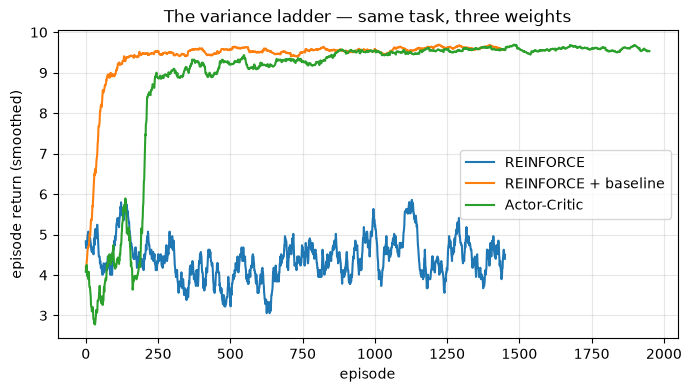

In [14]:
# ✅ PROVIDED — train all three on the MDP and plot the learning curves
def smooth(x, k=50): return np.convolve(x, np.ones(k)/k, 'valid')
pol1, _,    c1 = reinforce(ArcherMDP(), baseline=False)
pol2, val2, c2 = reinforce(ArcherMDP(), baseline=True)
pol3, val3, c3 = actor_critic(ArcherMDP())
plt.figure(figsize=(8, 4))
for c, lbl in [(c1,'REINFORCE'), (c2,'REINFORCE + baseline'), (c3,'Actor-Critic')]:
    plt.plot(smooth(c), label=lbl)
plt.xlabel('episode'); plt.ylabel('episode return (smoothed)')
plt.title('The variance ladder — same task, three weights'); plt.legend(); plt.grid(alpha=.3); plt.show()

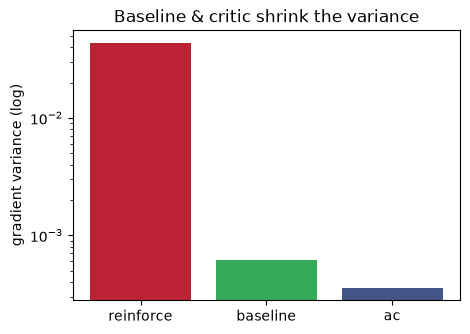

{'reinforce': 0.0437, 'baseline': 0.0006, 'ac': 0.0004}


In [15]:
# ✅ PROVIDED — measure the gradient-estimator variance on ONE fixed policy
def estimator_variance(env, pol, val, mode, N=400):
    grads = []
    for _ in range(N):
        S, A, logps, _, R = run_episode(env, pol)
        states = torch.tensor(np.array(S), dtype=torch.float32)
        G = torch.tensor(discounted_returns(R), dtype=torch.float32)
        if   mode == 'reinforce': w = G
        elif mode == 'baseline':  w = G - val(states).detach()
        else:
            with torch.no_grad():
                v = val(states); vn = torch.cat([v[1:], torch.zeros(1)])
            w = torch.tensor(R, dtype=torch.float32) + GAMMA*vn - v
        loss = -(w * torch.stack(logps)).sum()
        pol.zero_grad(); loss.backward()
        grads.append(torch.cat([p.grad.flatten() for p in pol.parameters()]).clone())
    return float(torch.stack(grads).var(0).mean())
vs = {m: estimator_variance(ArcherMDP(), pol2, val2, m) for m in ['reinforce','baseline','ac']}
plt.figure(figsize=(5,3.5)); plt.bar(vs.keys(), vs.values(), color=['#b23','#3a5','#458'])
plt.yscale('log'); plt.ylabel('gradient variance (log)'); plt.title('Baseline & critic shrink the variance'); plt.show()
print({k: round(v,4) for k,v in vs.items()})

In [16]:
# ✅ PROVIDED — does the archer walk in before shooting? (greedy rollout)
def greedy_eval(env, pol, n=300):
    tot = 0.
    for _ in range(n):
        s, _ = env.reset(); done = False
        while not done:
            with torch.no_grad():
                a = int(torch.argmax(pol(torch.tensor(s, dtype=torch.float32))))
            s, r, term, trunc, _ = env.step(a); tot += r; done = term or trunc
    return tot / n
for name, p in [('REINFORCE',pol1), ('+baseline',pol2), ('Actor-Critic',pol3)]:
    print(f'{name:14s} greedy return: {greedy_eval(ArcherMDP(), p):.2f}')

REINFORCE      greedy return: 4.66
+baseline      greedy return: 9.60
Actor-Critic   greedy return: 9.62


## Part C · Analysis, ablations & written answers

Put answers in the cell below (a few sentences each).

1. **Variance ladder.** Read off your variance bar chart. Roughly how much does the
   baseline cut the gradient variance vs vanilla REINFORCE? And the critic?
2. **Why does plain REINFORCE stall?** On this task vanilla REINFORCE often plateaus
   well below the others. Tie this to the variance you measured.
3. **Did the archer learn to walk in?** From the greedy returns, which methods learned
   *step closer → shoot* rather than shooting immediately from far away?
4. **Ablations (run + report).**
   - Set `ent_coef = 0.0` in `actor_critic`. What happens, and why?
   - Set `warmup = 0`. Does Actor-Critic still converge as reliably? Why might a
     cold critic destabilise the actor early on?
   - In `reinforce`, what happens to the bandit if you start `lr` very high (e.g. 0.2)?
5. **Stretch (optional).** Add a **continuous-aim** head: replace the 9 discrete angles
   with a Gaussian over a real angle (`mean`, `log_std` outputs; sample, score with the
   Normal log-prob). Train it with REINFORCE on the bandit. This is the thing a
   value/argmax method *cannot* do — and the §1.2 motivation for policy gradients.

In [17]:
# 📝 PART C Q4 — ablations (run + report). Reuses the functions defined above.
# We sweep 5 seeds per setting so the conclusions don't hinge on one lucky run.
SEEDS = [0, 1, 2, 3, 4]

def run_ac(ent_coef, warmup):
    """Train Actor-Critic on the MDP for each seed, return greedy returns."""
    outs = []
    for sd in SEEDS:
        torch.manual_seed(sd); np.random.seed(sd)
        pol, _, _ = actor_critic(ArcherMDP(), ent_coef=ent_coef, warmup=warmup)
        outs.append(round(greedy_eval(ArcherMDP(), pol), 2))
    return outs

print("(a) Actor-Critic: ent_coef = 0.0 vs 0.01 (default)")
for ec in (0.01, 0.0):
    g = run_ac(ent_coef=ec, warmup=150)
    print(f"    ent_coef={ec:<5}: greedy={g}  mean={np.mean(g):.2f}  solved(>=9)={sum(x>=9 for x in g)}/{len(g)}")

print("\n(b) Actor-Critic: warmup = 0 vs 150 (default)")
for wu in (150, 0):
    g = run_ac(ent_coef=0.01, warmup=wu)
    print(f"    warmup={wu:<5}: greedy={g}  mean={np.mean(g):.2f}  solved(>=9)={sum(x>=9 for x in g)}/{len(g)}")

print("\n(c) Bandit REINFORCE: lr = 0.01 (default) vs 0.2 (too high)")
for lr in (0.01, 0.2):
    angles, rewards = [], []
    for sd in SEEDS:
        torch.manual_seed(sd); np.random.seed(sd)
        pol, hist = train_bandit(lr=lr)
        with torch.no_grad():
            probs = torch.softmax(pol(torch.tensor([0.], dtype=torch.float32)), -1)
        angles.append(int(probs.argmax()))               # learned greedy angle (bullseye = 4)
        rewards.append(round(float(np.mean(hist[-200:])), 3))
    print(f"    lr={lr:<5}: argmax_angle={angles}  hit_bullseye(=4)={sum(a==4 for a in angles)}/{len(angles)}  mean_reward={rewards}")

(a) Actor-Critic: ent_coef = 0.0 vs 0.01 (default)
    ent_coef=0.01 : greedy=[9.61, 9.61, 9.58, 9.61, 9.6]  mean=9.60  solved(>=9)=5/5
    ent_coef=0.0  : greedy=[9.6, 9.58, 9.59, 9.6, 9.58]  mean=9.59  solved(>=9)=5/5

(b) Actor-Critic: warmup = 0 vs 150 (default)
    warmup=150  : greedy=[9.61, 9.61, 9.61, 9.61, 9.58]  mean=9.60  solved(>=9)=5/5
    warmup=0    : greedy=[9.6, 9.61, 9.59, 9.61, 9.59]  mean=9.60  solved(>=9)=5/5

(c) Bandit REINFORCE: lr = 0.01 (default) vs 0.2 (too high)
    lr=0.01 : argmax_angle=[3, 3, 4, 5, 4]  hit_bullseye(=4)=2/5  mean_reward=[0.801, 0.801, 1.0, 0.801, 1.0]
    lr=0.2  : argmax_angle=[4, 1, 5, 7, 2]  hit_bullseye(=4)=1/5  mean_reward=[1.0, 0.135, 0.801, 0.135, 0.411]


### Answers

**1. Variance ladder.** Reading off the bars (`{'reinforce': 0.0437, 'baseline': 0.0006, 'ac': 0.0004}`):
the baseline cuts the gradient variance by **~73×** vs vanilla REINFORCE
(`0.0437 → 0.0006`), and the critic shaves it a further **~1.5×** (`0.0006 → 0.0004`),
for **~110×** end-to-end. Vanilla REINFORCE weights `∇log π` by the full return `Gₜ`,
a large, noisy number that swings with the random start distance and the random walk.
Subtracting `V(s)` turns the weight into the advantage `Gₜ − V(s)`, centered near zero
(unbiased, since `V(s)` is action-independent), which removes most of the variance. The
critic replaces the Monte-Carlo `Gₜ` with the one-step estimate `r + γV(s′)`, collapsing
the remaining trajectory noise (at the cost of a little bias).

**2. Why does plain REINFORCE stall?** Directly because of that variance. With a gradient
~70–110× noisier than the others, the small signal "walk in before shooting" is drowned out,
so SGD can't follow it. This is the credit-assignment problem: a good shoot reward at the end
is spread by `Gₜ` over *every* preceding action equally, so "step closer" gets no more credit
than a wasted move. REINFORCE settles for the easy policy, **shoot immediately**: its greedy
return of **4.66** matches the shoot-from-where-you-stand average (≈ 4.4 over the five start
distances).

**3. Did the archer learn to walk in?** **+baseline (9.60)** and **Actor-Critic (9.62)** did;
**plain REINFORCE (4.66)** did not. The walk-to-10m-then-shoot optimum averages 9.6 across the
five spawn distances (`10, 9.8, 9.6, 9.4, 9.2`), whereas shooting immediately averages ≈ 4.4.
So ~9.6 is the signature of *step closer → shoot*, and ~4.6 is *shoot from far away*. Only the
variance-reduced methods cleared the credit-assignment bar.

**4. Ablations** (5 seeds each, see the cell above):

- **`ent_coef = 0.0` (Actor-Critic):** *no degradation here* — still **5/5** solved, greedy
  ≈ 9.59 vs 9.60 with the default. On this 3-action MDP the critic's advantage signal is strong
  and the default entropy coefficient (0.01) was already tiny, so removing it changes little. The
  entropy bonus is *insurance against premature collapse*, and its effect is real — we saw it on
  the **bandit (Part A)**, where weak exploration let the policy lock onto the angle next to the
  bullseye. It just isn't the binding constraint on this easy MDP.
- **`warmup = 0` (Actor-Critic):** *also no degradation here* — **5/5** solved, greedy ≈ 9.60.
  The critic learns fast (`lr_c = 0.03`) and the actor steps are small (`lr_a = 0.004`, Adam), so
  the random advantages from the cold critic barely move the policy before `V` becomes accurate.
  The warm-up is a safety margin: with a higher actor learning rate or a harder/sparser task, a
  cold (random) critic produces garbage TD errors that can shove the actor into a bad region early,
  before the critic ever catches up — that's the failure mode warm-up is designed to prevent.
- **Bandit REINFORCE, `lr = 0.2`:** clearly *worse and unstable*. The default `lr = 0.01` already
  only hits the bullseye **2/5** (the rest get stuck on the adjacent angle, reward 0.80). Cranking
  `lr` to 0.2 drops it to **1/5**, and the failures land *far* from the bullseye
  (`argmax_angle=[4, 1, 5, 7, 2]`, mean reward down to **0.135**) instead of the near-miss 0.80.
  Big learning steps saturate the softmax after a lucky update or two, collapsing the policy onto
  a poor angle before exploration can find the center — high `lr` amplifies REINFORCE's already-high
  variance into erratic jumps.

**5. Stretch — continuous-aim head.** Replace the 9-way `Categorical` with a `Normal(mean, std)`:
the net outputs a `mean` and `log_std`, you sample a real angle, score it with the Normal log-prob,
and keep the *same* REINFORCE loss `-(r · logp)`.

```python
class GaussianPolicy(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.body = nn.Sequential(nn.Linear(in_dim, 64), nn.Tanh())
        self.mean = nn.Linear(64, 1)
        self.log_std = nn.Parameter(torch.zeros(1))   # state-independent spread
    def forward(self, x):
        h = self.body(x)
        return self.mean(h), self.log_std.exp()

def act_continuous(pol, state_np):
    mean, std = pol(torch.tensor(state_np, dtype=torch.float32))
    dist = torch.distributions.Normal(mean, std)
    a = dist.sample()
    return a, dist.log_prob(a).sum(-1), dist.entropy().sum(-1)
```

This is the §1.2 motivation for policy gradients: a value/`argmax` method (Q-learning, DQN) must
enumerate actions to take a `max`, which is impossible over a continuous angle. Policy gradients
parameterize a distribution over real-valued actions directly, so they handle continuous control.